# Prep data for forecasting

In [1]:
# Standard data analysis packages
import datetime
import pandas as pd
import numpy as np
import glob as glob
import os
from pandas.tseries.offsets import Day, BDay

# Antigen analysis package
from antigentools.io import (
    AntigenReader
)
from antigentools.utils import (
    translate_dna_to_aa,
)
import antigentools.plot as aplt

# Plotting packages
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Machine learning packages
from sklearn.cluster import KMeans
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
)
from sklearn.preprocessing import StandardScaler

In [4]:
def bin_dates(df, ref_date='2020-01-01', bin_days=[7, 14, 21]):
    """
    Bins the dates in the dataframe.

    Parameters
    ----------
    df : pd.DataFrame
        Dataframe with a 'year' column.
    ref_date : str
        Reference date to calculate initial dates.
    bin_days : list
        Days to bin the dates to.

    Returns
    -------
    pd.DataFrame
        Dataframe with a 'binned_date' column.
    """
    reference_date = pd.Timestamp(ref_date)

    # Create the date column
    df['date'] = reference_date + pd.to_timedelta(df['year'] * 365.25, unit='D')
    
    # Ensure bin_days is sorted
    bin_days = sorted(bin_days)

    def bin_date(date):
        start_date = date.replace(day=1)  # Start of the month
        last_day_of_month = (start_date + pd.offsets.MonthEnd(0)).day  # Last day of the month
        
        # Find the appropriate bin day
        for bin_day in bin_days:
            if date.day <= bin_day:
                return start_date + pd.to_timedelta(bin_day - 1, unit='D')
        
        # If no bin day matches, group to the last day of the month
        return start_date + pd.to_timedelta(last_day_of_month - 1, unit='D')

    # Apply the binning function
    df['binned_date'] = df['date'].apply(bin_date)

    return df

In [6]:
def prep_cases_dataframe(cases_df, ref_date='2020-01-01'):
    """ Melt a dataframe containing cases and convert floating point dates to datetime objects.

    Parameters
    ----------
    cases_df : pd.DataFrame
        A dataframe containing cases data.
    ref_date : str
        A reference date to convert floating point dates to datetime objects.

    Returns
    -------
    pd.DataFrame
        A melted dataframe containing case counts for each deme/country over time.
    """
    if 'year' not in cases_df.columns and 'date' in cases_df.columns:
        cases_df.rename(columns={'date': 'year'}, inplace=True)
    
    # Round dates for smoother date assignments
    cases_df['rounded_year'] = cases_df['year'].apply(lambda x: round(x,3))

    # Define a reference date
    reference_date = pd.Timestamp(ref_date)  # Choose a reference date within the supported range

    # Convert the floating point decimals to days and then add to the reference date
    cases_df['date'] = reference_date + pd.to_timedelta(cases_df['rounded_year'] * 365, unit='D')

    # Convert datetime objects to the desired format (yyyy-mm-dd)
    cases_df['date'] = cases_df['date'].dt.strftime('%Y-%m-%d')
    cases_df['date'] = pd.to_datetime(cases_df['date'])
    
    # Melt the DataFrame
    cases_melted = pd.melt(cases_df, id_vars=['date'], value_vars=['northCases', 'southCases', 'tropicsCases'], var_name='country', value_name='cases')

    # Replace 'Cases' in country names with an empty string
    cases_melted['country'] = cases_melted['country'].str.replace('Cases', '')

    return cases_melted

In [7]:
def normalize_case_counts(cases_df, population_size = 30_000_000):
    """Helper function to normalize raw case counts to cases per 100k in the population.

    Parameters
    ----------
    cases_df : pd.DataFrame
        A dataframe containing cases data.
    population_size : int
        The population size of the deme/country (assumed to be equal for all demes/countries).

    Returns
    -------
    pd.DataFrame
        A dataframe containing normalized case counts per 100k in the population.
    """
    # Make cases per 100k in the population
    cases_df['northCases'] = ((cases_df['northCases'] / population_size) * 100_000).astype(int)
    cases_df['southCases'] = ((cases_df['southCases'] / population_size) * 100_000).astype(int)
    cases_df['tropicsCases'] = ((cases_df['tropicsCases'] / population_size) * 100_000).astype(int)

    return cases_df

In [8]:
def filter_to_lifespan(df: pd.DataFrame, variant: str, lifespan: tuple) -> pd.DataFrame:
    """ Pre-process fitness dataframe to set all fitness values outside of the lifespan of a variant to NaN.

    Parameters:
    ---------------
        df (pd.DataFrame): Dataframe with columns 'time', 'fitness', 'variant'
        variant (str): Variant name
        lifespan (tuple): Tuple of start and end dates

    Returns:
    ---------------
        pd.DataFrame: Filtered dataframe
    """
    start, end = lifespan
    # Set fitness values of variant outside of lifespan to NaN
    # Query variant 
    var_df = df.query(f"variant == {variant}")
    # Set fitness values outside of lifespan to NaN
    var_df.loc[(var_df['time'] < start) | (var_df['time'] > end), 'fitness'] = np.nan

    return var_df

def prune_fitness_dataframe(fitness_df: pd.DataFrame, centroids_df: pd.DataFrame) -> pd.DataFrame:
    """ Prune fitness dataframe to only include data within lifespan.

    Parameters:
    ---------------
        fitness_df (pd.DataFrame): Dataframe with columns 'time', 'fitness', 'variant'
        centroids_df (pd.DataFrame): Dataframe with columns 'variant', 'birth', 'death'

    Returns:
    ---------------
        pruned_df (pd.DataFrame): Dataframe
    """
    variant_dfs = []
    for variant in fitness_df['variant'].unique():
        # Get lifespan of variant
        lifespan = centroids_df.query(f"variant == {variant}")[['birth', 'death']].values[0]
        # Prune dataframe
        pruned_df = filter_to_lifespan(fitness_df, variant, lifespan)
        variant_dfs.append(pruned_df)
    pruned_df = pd.concat(variant_dfs)
    return pruned_df

In [9]:
def plot_variant_lifespans(variant_centroids_df, classifier=None):
    """
    Plot the lifespans of the variants.

    Parameters
    ----------
    variant_centroids_df : pd.DataFrame
        Dataframe with variant centroids, birth, and death times.
    classifier : str
        Classifier used to assign variants. Places in title.

    Returns
    -------
    None
    """
    # Plotting lifespans of variants
    plt.figure(figsize=(10, 8))

    # Loop through each unique variant and plot a bar from birth to death
    for i, variant in enumerate(sorted(variant_centroids_df['variant'].unique())):
        subset = variant_centroids_df[variant_centroids_df['variant'] == variant]
        for _, row in subset.iterrows():
            plt.plot([row['birth'], row['death']], [i, i], color=palette[i], lw=8)

    # Customization
    plt.yticks(range(len(variant_centroids_df['variant'].unique())), sorted(variant_centroids_df['variant'].unique()))
    plt.xlim(0, 30)
    plt.xlabel('Time')
    plt.ylabel('Variant')
    if classifier:
        plt.title(f'Lifespans of Variants ({classifier})')
    else:
        plt.title('Lifespan of Variants')
    plt.grid(True)

    plt.show()

In [69]:
def cluster_embeddings(mds_df, k=25):
    """
    Cluster the MDS embeddings using KMeans clustering.

    Parameters
    ----------
    mds_df : pd.DataFrame
        Dataframe containing MDS embeddings.
    k : int
        Number of clusters to use.

    Returns
    -------
    pd.DataFrame
        Dataframe with an additional column 'variant_seq' containing the cluster labels.
    """
    # Use every mds column as a feature -- use regex to match columns
    X_seq = mds_df.filter(regex='mds').values
    X_seq = StandardScaler().fit_transform(X_seq)

    kmeans_model = KMeans(n_clusters=k, random_state=42).fit(X_seq)
    cluster_labels = kmeans_model.fit_predict(X_seq)
    mds_df['variant_seq'] = cluster_labels

    return mds_df

In [68]:
def merge_variant_dataframes(tips_df, mds_df):
    """ Merge the tips and mds dataframes on the 'name' column.

    Parameters
    ----------
    tips_df : pd.DataFrame
        A dataframe containing tips data.
    mds_df : pd.DataFrame
        A dataframe containing mds data.

    Returns
    -------
    pd.DataFrame
        A merged dataframe containing tips and cluster assignment -- alongside first two dimensions.
    """
    #Create a mapping of `nucleotideSequence` to `variant_seq`
    mapping = tips_df.merge(mds_df[['name', 'variant_seq', 'mds1', 'mds2']], on='name', how='inner')
    mapping = mapping.drop_duplicates(subset=['nucleotideSequence'])

    # Create a dictionary for mapping nucleotideSequence to variant_seq
    sequence_to_variant = dict(zip(mapping['nucleotideSequence'], mapping['variant_seq']))
    sequence_to_mds1 = dict(zip(mapping['nucleotideSequence'], mapping['mds1']))
    sequence_to_mds2 = dict(zip(mapping['nucleotideSequence'], mapping['mds2']))

    # Map variant_seq values to tips_df using the nucleotideSequence column
    tips_df['variant_seq'] = tips_df['nucleotideSequence'].map(sequence_to_variant)
    tips_df['mds1'] = tips_df['nucleotideSequence'].map(sequence_to_mds1)
    tips_df['mds2'] = tips_df['nucleotideSequence'].map(sequence_to_mds2)

    return tips_df

In [10]:
# Create color palette for the variants
# Generate colors from different palettes
palette1 = sns.color_palette("tab20", 20)
palette2 = sns.color_palette("tab20b", 20)
palette3 = sns.color_palette("tab20c", 20)
palette4 = sns.color_palette("Paired", 20)
palette5 = sns.color_palette("Accent", 20)
palette6 = sns.color_palette("Dark2", 20)

# Combine palettes
palette = palette1 + palette2 + palette3 + palette4 + palette5 + palette6

## Setup data

In [11]:
# Load large dataset
ag_build = "flu-simulated-150k-samples-antigenic-clusters"
seq_build = "flu-simulated-150k-samples-sequence-clusters"
tips_path = f"../data/{seq_build}/antigen-outputs/viruses.csv"
tips_df = pd.read_csv(tips_path)
demes = {0:"north", 1:"tropics", 2:"south"}
tips_df['country'] = tips_df['location'].map(demes)
tips_df.head()

,name,year,trunk,tip,mark,location,layout,nucleotideSequence,ag1,ag2,epitopeMutationCount,nonepitopeMutationCount,fitness,aa_seq,variant_ag,country
0,466dd9e7,-0.0781,0,1,0,1,633.0,ATGAAGACCATCATTGCTTTGAGCTACATTCTATGTCTGGTTTTCG...,16.8866,2.0590,11,2,0.4838,MKTIIALSYILCLVFAQKLPGNDNSTATLCLGHHAVPNGTIVKTIT...,2,tropics
1,2377549b,-0.0510,0,1,0,1,3205.0,ATGAAGACCATCATTGCTTTGAGCTACATTCTATGTCTGGTTTTCG...,16.8866,2.0590,11,3,0.5044,MKTIIALSYILCLVFAQKLPGNDNSTATLCLGHHAVPNGTIVKTIT...,2,tropics
2,2334ca5f,-0.0448,0,1,0,1,71.0,ATGAAGACCATCATTGCTTTGAGCTACATTCTATGTCTGGTTTTCG...,17.1318,-2.7725,10,2,0.5210,MKTIIALSYILCLVFAQKLPGNDNSTATLCLGHHAVPNGTIVKTIT...,22,tropics
3,b6cb75c,-0.0400,0,1,0,1,3268.0,ATGAAGACCATCATTGCTTTGAGCTACATTCTATGTCTGGTTTTCG...,16.8866,2.0590,11,3,0.4602,MKTIIALSYILCLVFAQKLPGNDNSTATLCLGHHAVPNGTIVKTIT...,2,tropics
4,3779009d,-0.0393,0,1,0,2,2524.0,ATGAAGACCATCATTGCTTTGAGCTACATTCTATGTCTGGTTTTCG...,16.8866,2.0590,11,3,0.5805,MKTIIALSYILCLVFAQKLPGNDNSTATLCLGHHAVPNGTIVKTIT...,2,south


## Try clustering the embedding space with various methods

In [26]:
mds_path = f"../data/{seq_build}/clades/mds-embeddings.csv"
mds_df = pd.read_csv(mds_path)
# Splitting the 'strain' column into three different components
mds_df[['name', 'date', 'fitness']] = mds_df['strain'].str.split('|', expand=True)

# Reordering the columns
new_column_order = ['name', 'date', 'fitness'] + [col for col in mds_df.columns if col not in ['name', 'date', 'fitness']]
mds_df = mds_df[new_column_order]
mds_df.drop(columns=['strain'], inplace=True)
mds_df.head()

,name,date,fitness,mds1,mds2,mds3,mds4,mds5,mds6,mds7,mds8,mds9,mds10
0,466dd9e7,-0.0781,0.4838,0.429971,5.028526,-3.042052,-3.693204,-7.017855,2.422883,4.730845,1.095403,4.316894,1.830594
1,2377549b,-0.051,0.5044,0.766656,5.443106,-3.961282,-3.944497,-7.004877,2.861923,5.101151,0.931268,5.193561,1.995934
2,3779009d,-0.0393,0.5805,0.466882,5.371699,-3.203917,-3.937613,-7.529701,3.129910,4.875668,1.552934,5.262575,1.144880
3,31b98cb3,-0.0227,0.5086,-0.234949,4.511078,-2.255983,-5.379695,-6.178983,2.238083,4.988173,0.699743,4.714603,1.002526
4,28230f7d,-0.0097,0.5363,0.639708,5.426573,-3.636625,-4.397699,-7.783386,3.230670,4.864273,1.023309,4.134629,1.170849


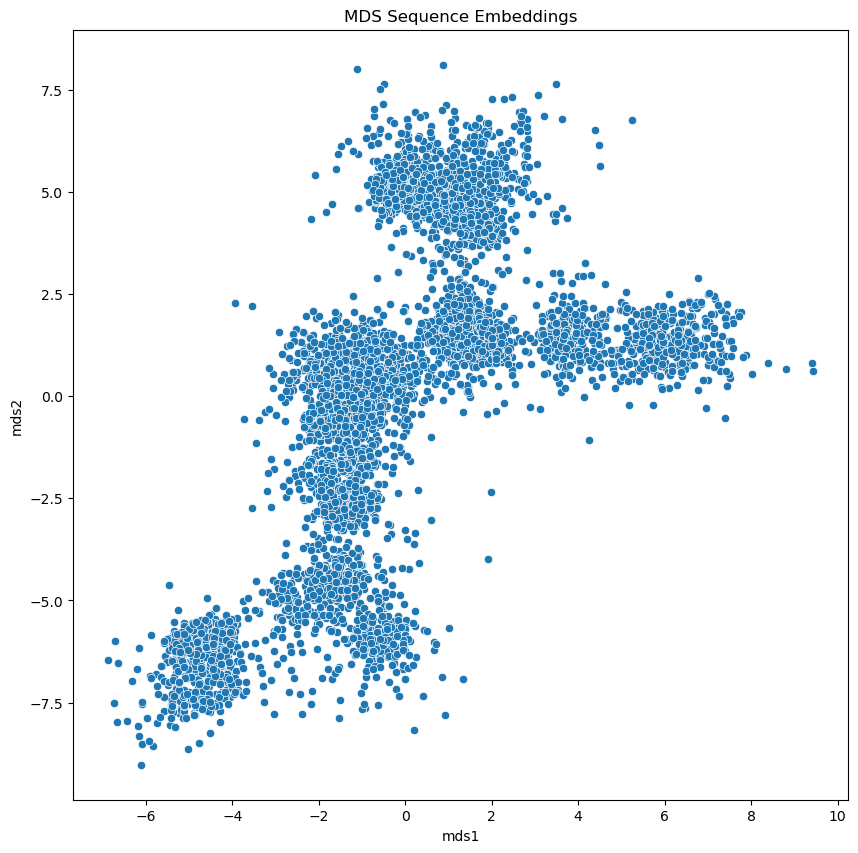

In [27]:
# Scatter of the embedding space
plt.figure(figsize=(10, 10))
sns.scatterplot(data=mds_df, x='mds1', y='mds2')
plt.title("MDS Sequence Embeddings")
plt.show()

In [28]:
# Conduct k-means clustering on the MDS embeddings
k = 25
# Use every mds column as a feature -- use regex to match columns
X_seq = mds_df.filter(regex='mds').values
X_seq = StandardScaler().fit_transform(X_seq)

kmeans_model = KMeans(n_clusters=k, random_state=42).fit(X_seq)
cluster_labels = kmeans_model.fit_predict(X_seq)
mds_df['variant_seq'] = cluster_labels
mds_df.head()

,name,date,fitness,mds1,mds2,mds3,mds4,mds5,mds6,mds7,mds8,mds9,mds10,variant_seq
0,466dd9e7,-0.0781,0.4838,0.429971,5.028526,-3.042052,-3.693204,-7.017855,2.422883,4.730845,1.095403,4.316894,1.830594,2
1,2377549b,-0.051,0.5044,0.766656,5.443106,-3.961282,-3.944497,-7.004877,2.861923,5.101151,0.931268,5.193561,1.995934,15
2,3779009d,-0.0393,0.5805,0.466882,5.371699,-3.203917,-3.937613,-7.529701,3.129910,4.875668,1.552934,5.262575,1.144880,2
3,31b98cb3,-0.0227,0.5086,-0.234949,4.511078,-2.255983,-5.379695,-6.178983,2.238083,4.988173,0.699743,4.714603,1.002526,2
4,28230f7d,-0.0097,0.5363,0.639708,5.426573,-3.636625,-4.397699,-7.783386,3.230670,4.864273,1.023309,4.134629,1.170849,2


## Compare clustering results

In [29]:
# Create a mapping of `nucleotideSequence` to `variant_seq`
mapping = tips_df.merge(mds_df[['name', 'variant_seq', 'mds1', 'mds2']], on='name', how='inner')
mapping = mapping.drop_duplicates(subset=['nucleotideSequence'])

# Create a dictionary for mapping nucleotideSequence to variant_seq
sequence_to_variant = dict(zip(mapping['nucleotideSequence'], mapping['variant_seq']))
sequence_to_mds1 = dict(zip(mapping['nucleotideSequence'], mapping['mds1']))
sequence_to_mds2 = dict(zip(mapping['nucleotideSequence'], mapping['mds2']))

In [31]:
# Map variant_seq values to tips_df using the nucleotideSequence column
tips_df['variant_seq'] = tips_df['nucleotideSequence'].map(sequence_to_variant)
tips_df['mds1'] = tips_df['nucleotideSequence'].map(sequence_to_mds1)
tips_df['mds2'] = tips_df['nucleotideSequence'].map(sequence_to_mds2)
tips_df.head()

,name,year,trunk,tip,mark,location,layout,nucleotideSequence,ag1,ag2,epitopeMutationCount,nonepitopeMutationCount,fitness,aa_seq,variant_ag,country,variant_seq,mds1,mds2
0,466dd9e7,-0.0781,0,1,0,1,633.0,ATGAAGACCATCATTGCTTTGAGCTACATTCTATGTCTGGTTTTCG...,16.8866,2.0590,11,2,0.4838,MKTIIALSYILCLVFAQKLPGNDNSTATLCLGHHAVPNGTIVKTIT...,2,tropics,2,0.429971,5.028526
1,2377549b,-0.0510,0,1,0,1,3205.0,ATGAAGACCATCATTGCTTTGAGCTACATTCTATGTCTGGTTTTCG...,16.8866,2.0590,11,3,0.5044,MKTIIALSYILCLVFAQKLPGNDNSTATLCLGHHAVPNGTIVKTIT...,2,tropics,15,0.766656,5.443106
2,2334ca5f,-0.0448,0,1,0,1,71.0,ATGAAGACCATCATTGCTTTGAGCTACATTCTATGTCTGGTTTTCG...,17.1318,-2.7725,10,2,0.5210,MKTIIALSYILCLVFAQKLPGNDNSTATLCLGHHAVPNGTIVKTIT...,22,tropics,24,-0.609791,4.854184
3,b6cb75c,-0.0400,0,1,0,1,3268.0,ATGAAGACCATCATTGCTTTGAGCTACATTCTATGTCTGGTTTTCG...,16.8866,2.0590,11,3,0.4602,MKTIIALSYILCLVFAQKLPGNDNSTATLCLGHHAVPNGTIVKTIT...,2,tropics,15,0.766656,5.443106
4,3779009d,-0.0393,0,1,0,2,2524.0,ATGAAGACCATCATTGCTTTGAGCTACATTCTATGTCTGGTTTTCG...,16.8866,2.0590,11,3,0.5805,MKTIIALSYILCLVFAQKLPGNDNSTATLCLGHHAVPNGTIVKTIT...,2,south,2,0.466882,5.371699


In [32]:
# Create a color map for the variants
variant_colors = sns.color_palette("tab20", k)
variant_colors = dict(zip(range(k), variant_colors))

In [44]:
# Calculate adjusted rand index -- how well do the clusters agree?
# Ranges from -1 (completely disagree) to 1 (completely agree)
ari = adjusted_rand_score(tips_df['variant_ag'], tips_df['variant_seq'])

# Calculate normalized mutual information score -- ranges from 0 (no agreement) to 1 (perfect agreement)
nmi = normalized_mutual_info_score(tips_df['variant_ag'], tips_df['variant_seq'], average_method='arithmetic')

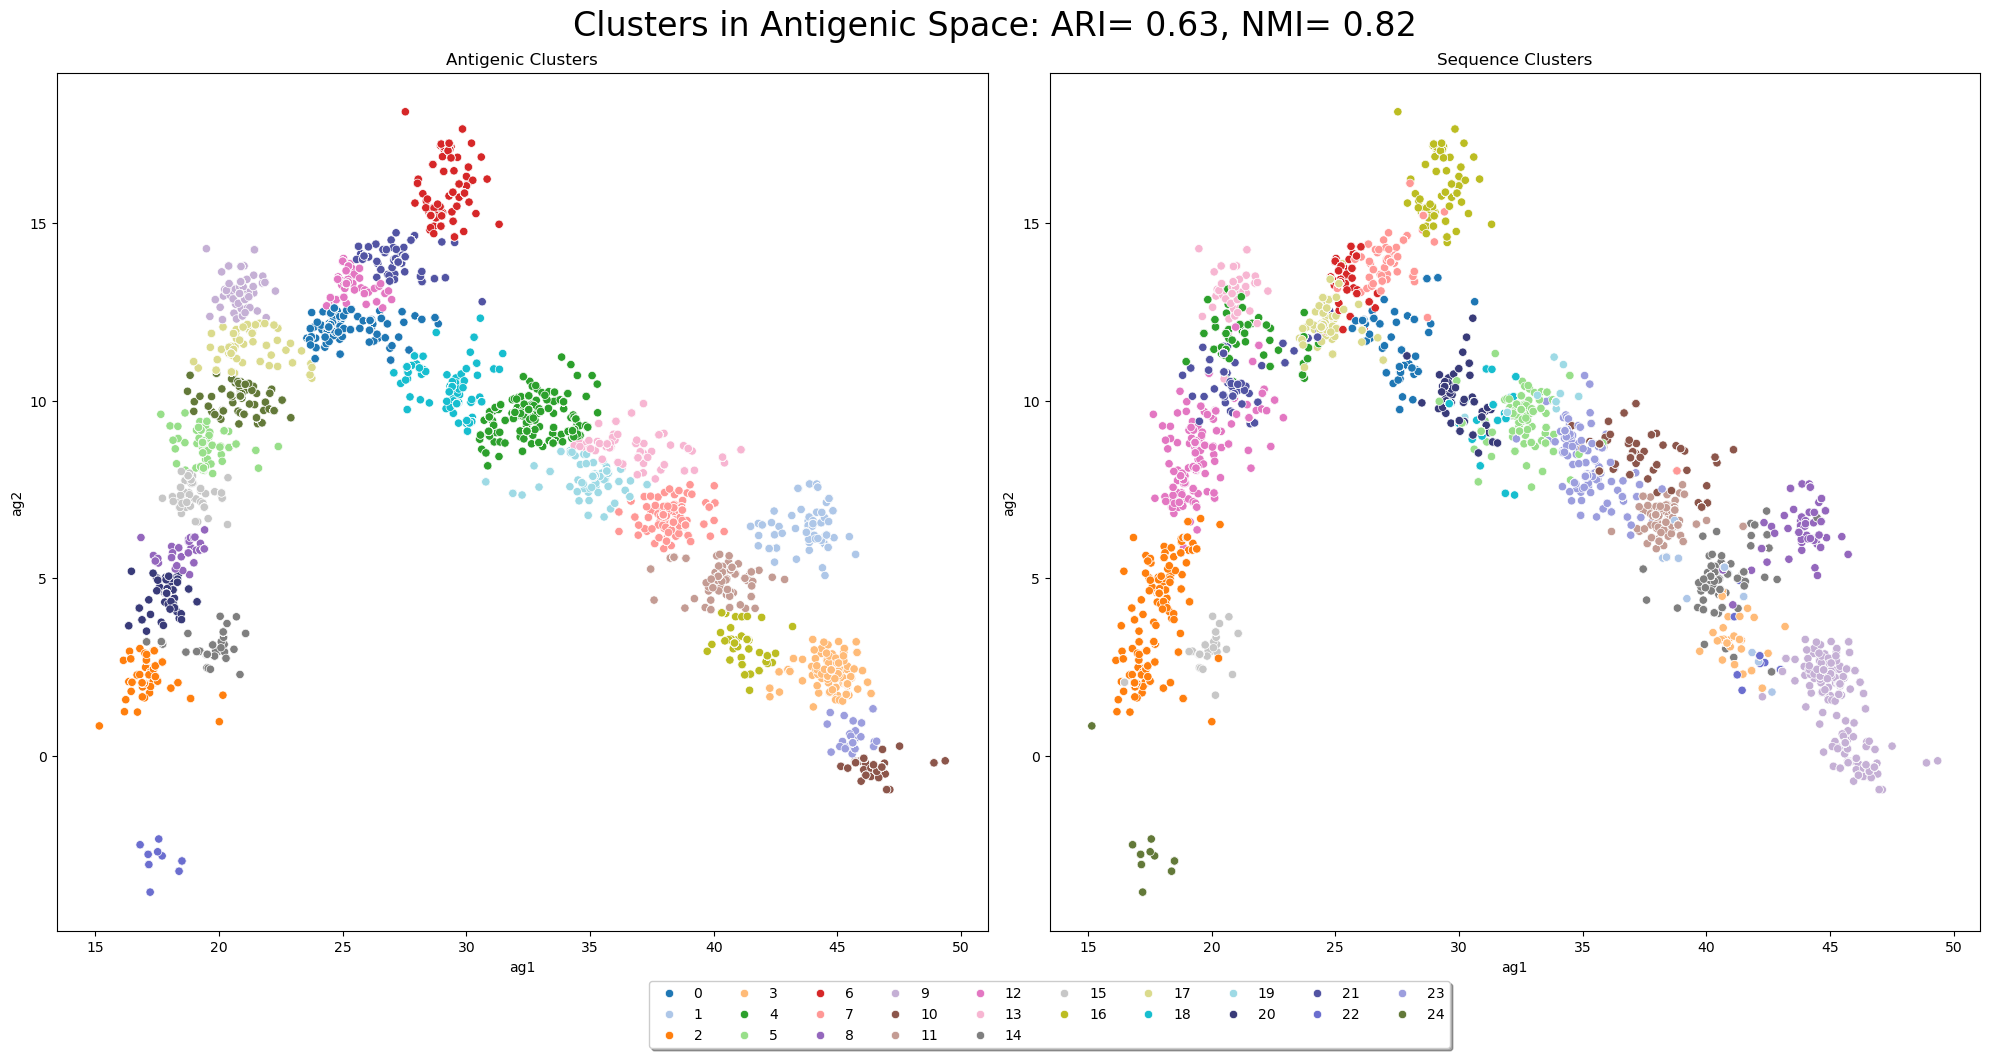

In [45]:
# Create 1x2 grid of plots
fig, axs = plt.subplots(1, 2, figsize=(20, 10))
fig.suptitle(f"Clusters in Antigenic Space: ARI= {ari:.2f}, NMI= {nmi:.2f}", fontsize=24)
# Scatterplot of merged_df on the left
sns.scatterplot(data=tips_df, x='ag1', y='ag2', hue='variant_ag', palette=palette[:k], ax=axs[0])
axs[0].set_title("Antigenic Clusters")
# Remove legend from axes
sns.scatterplot(data=tips_df, x='ag1', y='ag2', hue='variant_seq', palette=palette[:k], ax=axs[1])
axs[1].set_title("Sequence Clusters")
axs[0].get_legend().remove()
axs[1].get_legend().remove()
plt.tight_layout()
# Place legend below the figure
plt.legend(loc='upper center', bbox_to_anchor=(0.0, -0.05), shadow=True, ncol=10)
plt.show()

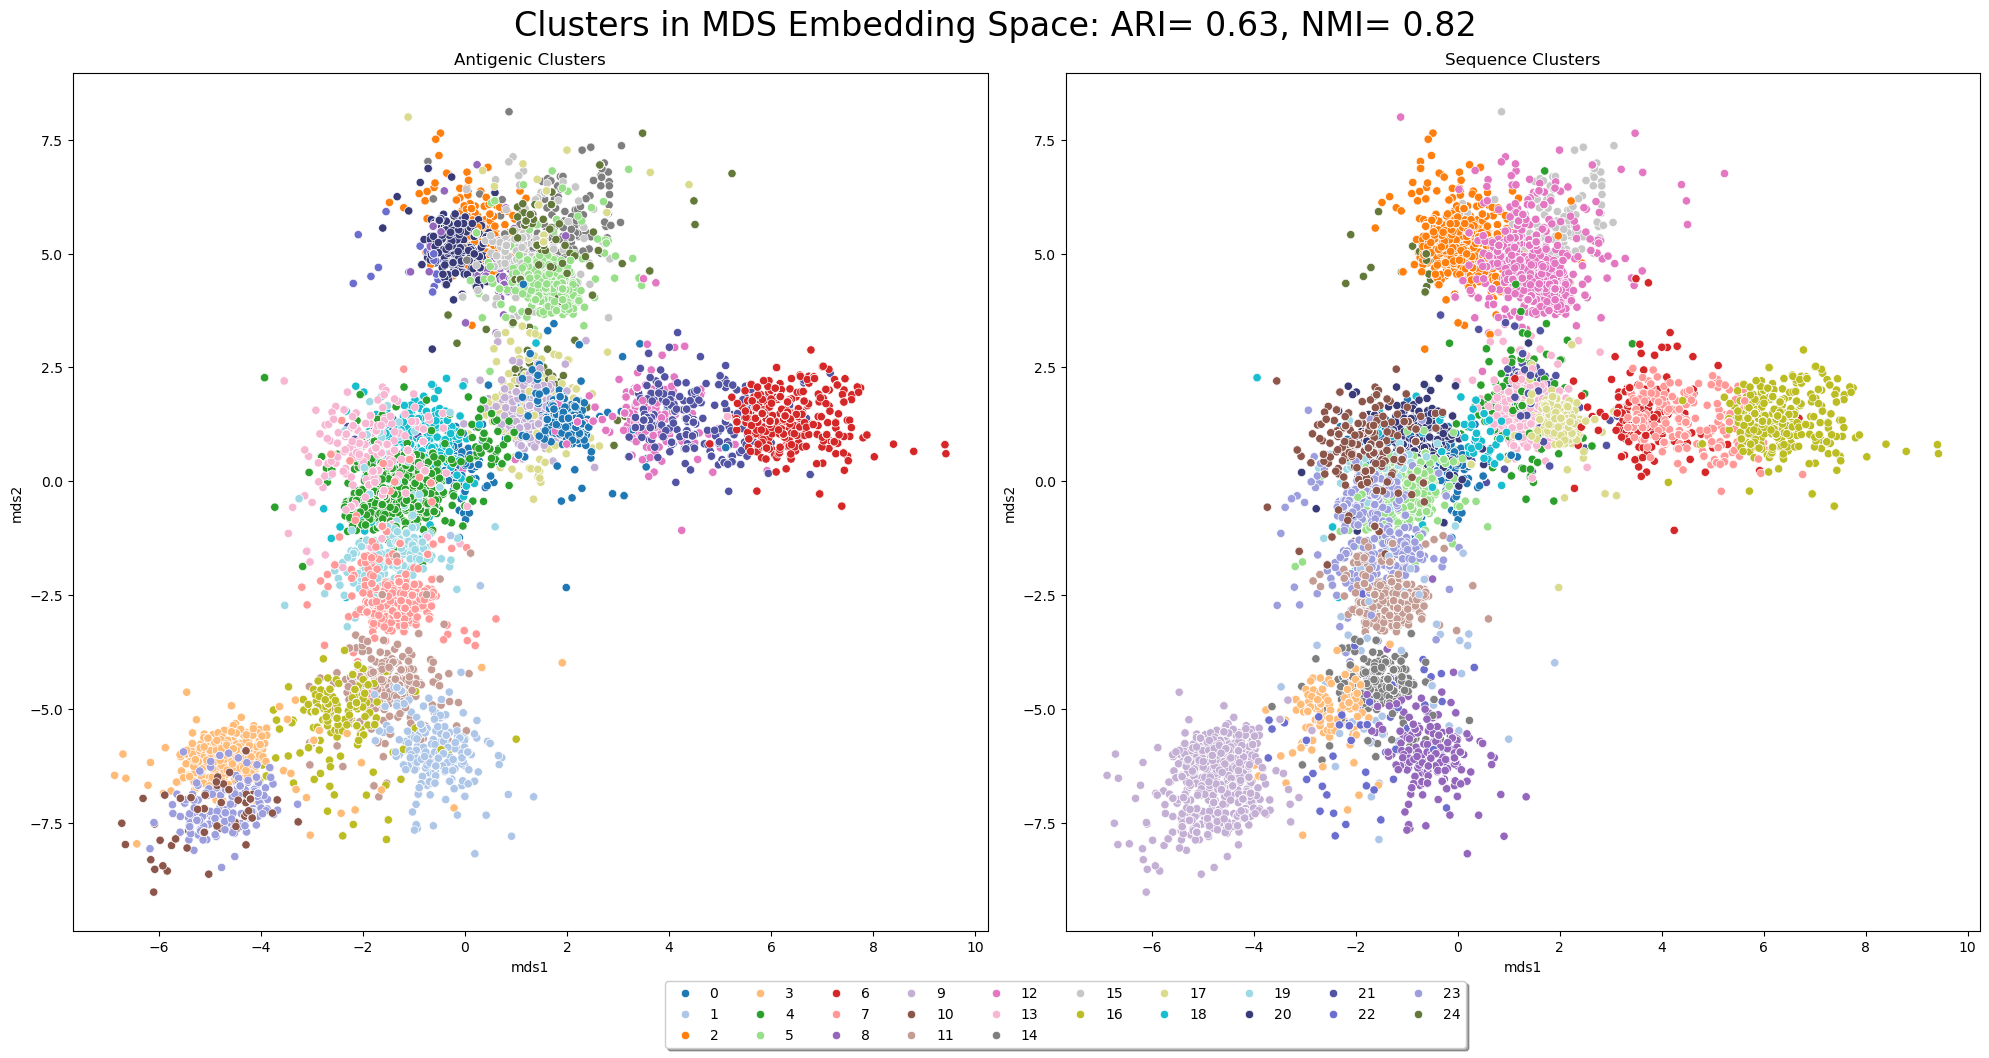

In [46]:
# Create 1x2 grid of plots
fig, axs = plt.subplots(1, 2, figsize=(20, 10))
fig.suptitle(f"Clusters in MDS Embedding Space: ARI= {ari:.2f}, NMI= {nmi:.2f}", fontsize=24)
# Scatterplot of merged_df on the left
sns.scatterplot(data=tips_df, x='mds1', y='mds2', hue='variant_ag', palette=palette[:k], ax=axs[0])
axs[0].set_title("Antigenic Clusters")
# Remove legend from axes
sns.scatterplot(data=tips_df, x='mds1', y='mds2', hue='variant_seq', palette=palette[:k], ax=axs[1])
axs[1].set_title("Sequence Clusters")
axs[0].get_legend().remove()
axs[1].get_legend().remove()
plt.tight_layout()
# Place legend below the figure
plt.legend(loc='upper center', bbox_to_anchor=(0.0, -0.05), shadow=True, ncol=10)
plt.show()

## Embedding space experiment

How does cluster agreement change with varying MDS embedding size?

``` pathogen-embed --alignment data/flu-simulated-150k-samples-sequence-clusters/clades/sequences.alignment --distance-matrix data/flu-simulated-150k-samples-sequence-clusters/clades/distance-matrix.csv --output-dataframe results/mds-experiments/embeddings_6.csv mds --components 6 ```

## Filter fitness to lifespan

**Antigenic-based command**

```python scripts/calc-variant-fitness.py data/flu-simulated-150k-samples-antigenic-clusters/viruses-clustered.csv data/flu-simulated-150k-samples-antigenic-clusters/antigen-outputs/out.histories data/flu-simulated-150k-samples-antigenic-clusters/clades/variant_fitness.csv --centroid-output data/flu-simulated-150k-samples-antigenic-clusters/clades/variant_centroids.csv --variant-col variant_ag```

**Sequence-based command**

```python scripts/calc-variant-fitness.py data/flu-simulated-150k-samples-sequence-clusters/viruses-clustered.csv data/flu-simulated-150k-samples-sequence-clusters/antigen-outputs/out.histories data/flu-simulated-150k-samples-sequence-clusters/clades/variant_fitness.csv --centroid-output data/flu-simulated-150k-samples-sequence-clusters/clades/variant_centroids.csv --variant-col variant_seq```

In [47]:
# Load in variant centroids and fitness
ag_centroids_df = pd.read_csv(f"../data/{ag_build}/clades/variant_centroids.csv")
ag_fitness_df = pd.read_csv(f"../data/{ag_build}/clades/variant_fitness.csv")
seq_centroids_df = pd.read_csv(f"../data/{seq_build}/clades/variant_centroids.csv")
seq_fitness_df = pd.read_csv(f"../data/{seq_build}/clades/variant_fitness.csv")

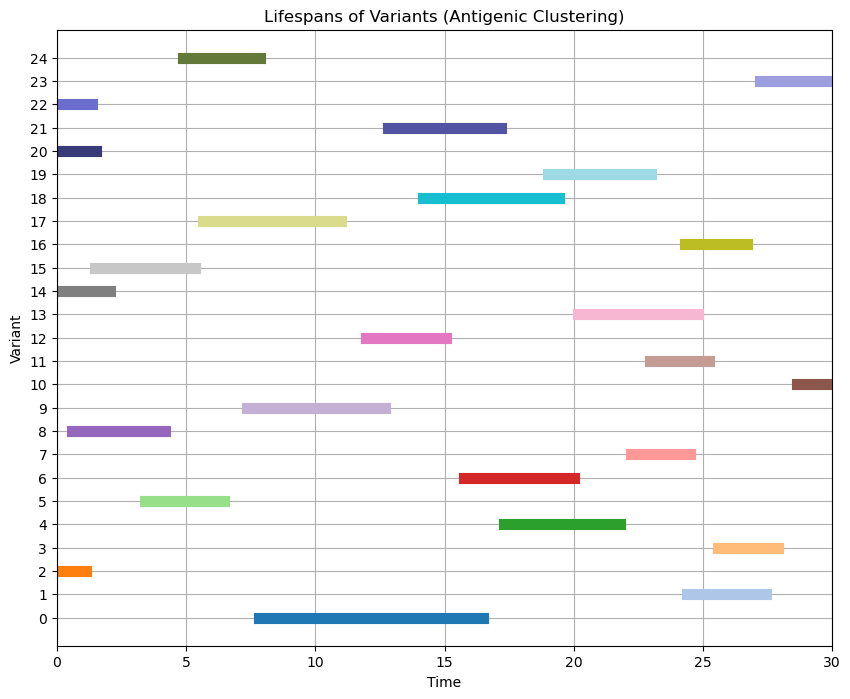

In [48]:
plot_variant_lifespans(ag_centroids_df, classifier='Antigenic Clustering')

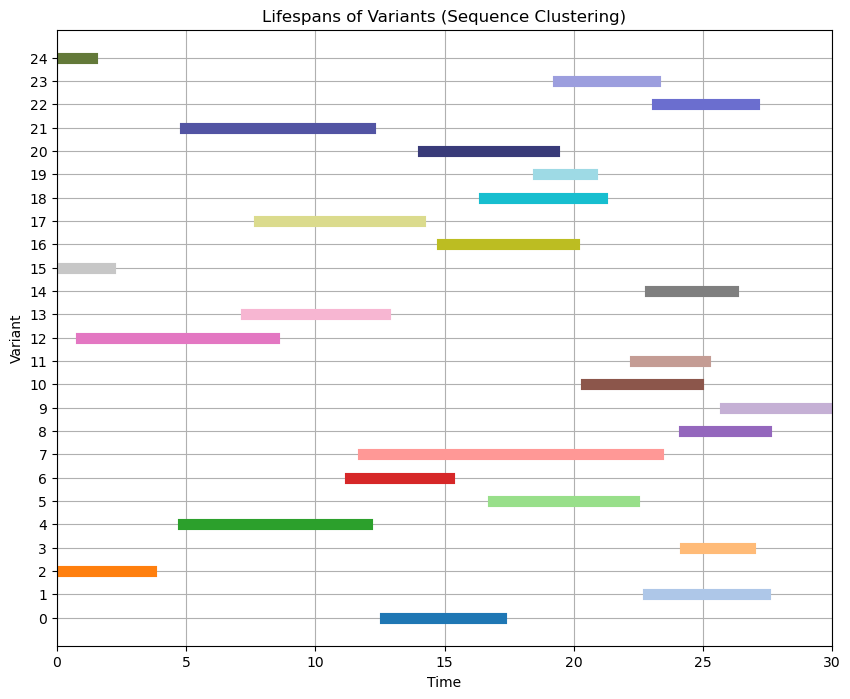

In [49]:
plot_variant_lifespans(seq_centroids_df, classifier='Sequence Clustering')

## Prepare sequence and case count data for antigenic-based variants

In [50]:
# Define the starting point (e.g., January 1, 2000)
start_date = pd.Timestamp('2020-01-01')

# Convert the 'year' column to datetime format
tips_df['date'] = start_date + pd.to_timedelta(tips_df['year'] * 365.25, unit='D')

# Adjust dates to the last day of the week
tips_df['date'] = tips_df['date'] + pd.offsets.Week(weekday=6)

# Format the new date column to '%Y-%m-%d'
tips_df['date'] = tips_df['date'].dt.strftime('%Y-%m-%d')

In [51]:
tips_df.head()

,name,year,trunk,tip,mark,location,layout,nucleotideSequence,ag1,ag2,epitopeMutationCount,nonepitopeMutationCount,fitness,aa_seq,variant_ag,country,variant_seq,mds1,mds2,date
0,466dd9e7,-0.0781,0,1,0,1,633.0,ATGAAGACCATCATTGCTTTGAGCTACATTCTATGTCTGGTTTTCG...,16.8866,2.0590,11,2,0.4838,MKTIIALSYILCLVFAQKLPGNDNSTATLCLGHHAVPNGTIVKTIT...,2,tropics,2,0.429971,5.028526,2019-12-08
1,2377549b,-0.0510,0,1,0,1,3205.0,ATGAAGACCATCATTGCTTTGAGCTACATTCTATGTCTGGTTTTCG...,16.8866,2.0590,11,3,0.5044,MKTIIALSYILCLVFAQKLPGNDNSTATLCLGHHAVPNGTIVKTIT...,2,tropics,15,0.766656,5.443106,2019-12-15
2,2334ca5f,-0.0448,0,1,0,1,71.0,ATGAAGACCATCATTGCTTTGAGCTACATTCTATGTCTGGTTTTCG...,17.1318,-2.7725,10,2,0.5210,MKTIIALSYILCLVFAQKLPGNDNSTATLCLGHHAVPNGTIVKTIT...,22,tropics,24,-0.609791,4.854184,2019-12-22
3,b6cb75c,-0.0400,0,1,0,1,3268.0,ATGAAGACCATCATTGCTTTGAGCTACATTCTATGTCTGGTTTTCG...,16.8866,2.0590,11,3,0.4602,MKTIIALSYILCLVFAQKLPGNDNSTATLCLGHHAVPNGTIVKTIT...,2,tropics,15,0.766656,5.443106,2019-12-22
4,3779009d,-0.0393,0,1,0,2,2524.0,ATGAAGACCATCATTGCTTTGAGCTACATTCTATGTCTGGTTTTCG...,16.8866,2.0590,11,3,0.5805,MKTIIALSYILCLVFAQKLPGNDNSTATLCLGHHAVPNGTIVKTIT...,2,south,2,0.466882,5.371699,2019-12-22


In [59]:
ag_counts_df = tips_df.groupby(['date', 'country', 'variant_ag']).size().reset_index(name='sequences')
ag_counts_df.rename(columns={'variant_ag': 'variant'}, inplace=True)
ag_counts_df.head()

,date,country,variant,sequences
0,2019-12-08,tropics,2,1
1,2019-12-15,tropics,2,1
2,2019-12-22,north,2,2
3,2019-12-22,south,2,2
4,2019-12-22,tropics,2,6


In [60]:
seqs_counts_df = tips_df.groupby(['date', 'country', 'variant_seq']).size().reset_index(name='sequences')
seqs_counts_df.rename(columns={'variant_seq': 'variant'}, inplace=True)
seqs_counts_df.head()

,date,country,variant,sequences
0,2019-12-08,tropics,2,1
1,2019-12-15,tropics,15,1
2,2019-12-22,north,2,1
3,2019-12-22,north,15,1
4,2019-12-22,south,2,2


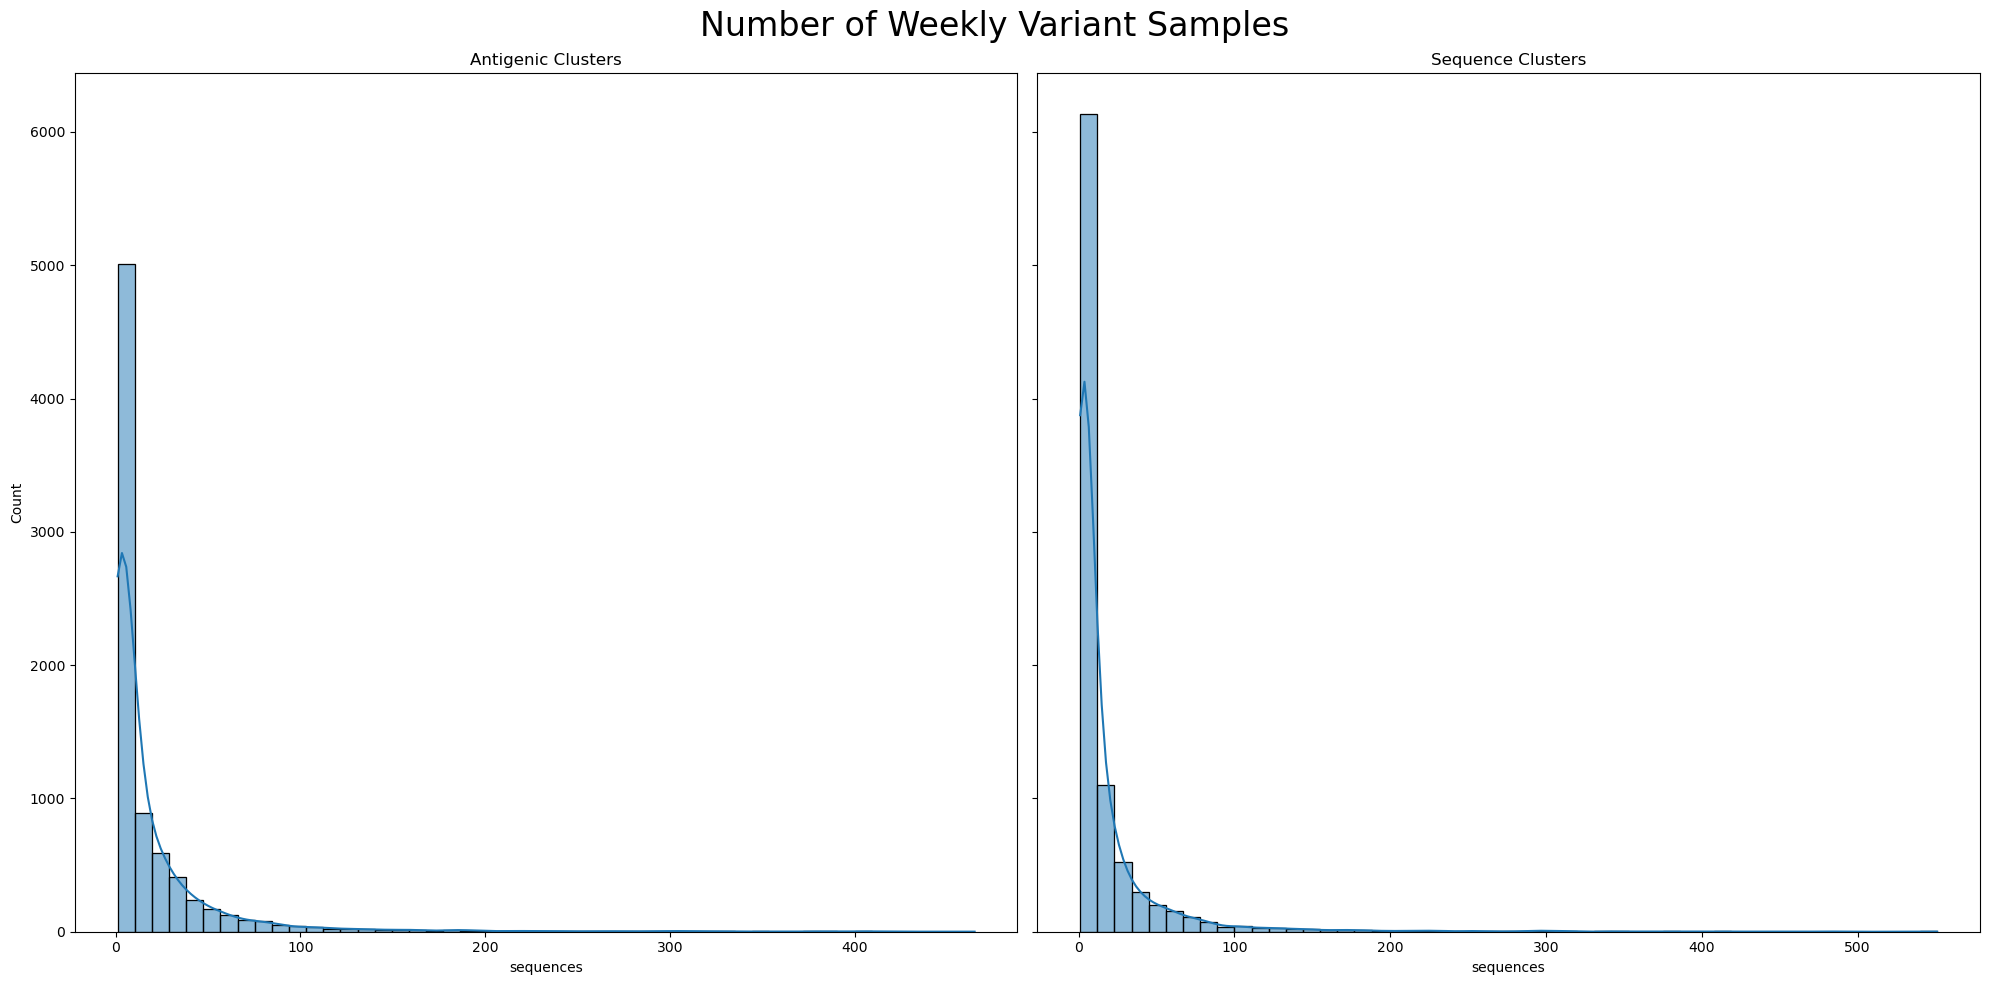

In [58]:
# Create a two pannel histogram of the number of sequences per variant
fig, axs = plt.subplots(1, 2, figsize=(20, 10), sharey=True)

fig.suptitle("Number of Weekly Variant Samples", fontsize=24)
# Plot the number of sequences per variant for antigenic clusters
sns.histplot(data=ag_counts_df, x='sequences', kde=True, bins=50, ax=axs[0])
axs[0].set_title("Antigenic Clusters")
#axs[0].set_yscale('log')
axs[0].set_ylabel('Count')

# Plot the number of sequences per variant for sequence clusters
sns.histplot(data=seqs_counts_df, x='sequences', kde=True, bins=50, ax=axs[1])
axs[1].set_title("Sequence Clusters")
#axs[1].set_yscale('log')
axs[1].set_ylabel('')
plt.tight_layout()
plt.show()

In [61]:
# Write sequence counts to file
ag_data_path = f"../data/{ag_build}/time-stamped/truth/"
seq_data_path = f"../data/{seq_build}/time-stamped/truth/"
# Make directories if they do not exist
os.makedirs(ag_data_path, exist_ok=True)
os.makedirs(seq_data_path, exist_ok=True)
ag_counts_df.to_csv(f"{ag_data_path}seq_counts.tsv", sep='\t', index=False)
seqs_counts_df.to_csv(f"{seq_data_path}seq_counts.tsv", sep='\t', index=False)

## Prep cases dataframe

In [62]:
# Load in cases data -- same simulation so the cases are shared.
cases_path = f"../data/{seq_build}/antigen-outputs/cases.csv"
cases_raw = pd.read_csv(cases_path)
cases_raw.head()

,date,diversity,tmrca,netau,serialInterval,antigenicDiversity,totalN,totalS,totalI,totalR,...,southDiversity,southTmrca,southNetau,southSerialInterval,southAntigenicDiversity,southN,southS,southI,southR,southCases
0,0.0110,2.4809,2.1378,inf,0.01478,1.2081,90000000,89791681,208319,0,...,2.1923,1.9446,inf,0.01596,0.4127,29999990,29965978,34012,0,44885
1,0.0301,2.5139,1.9636,inf,0.01374,1.2196,90000000,89804667,195333,0,...,2.2318,1.9630,273.9726,0.01607,0.4401,29999990,29972826,27164,0,35973
2,0.0493,2.5319,1.9830,inf,0.01459,1.1756,90000000,89813692,186308,0,...,2.2527,1.9829,273.9726,0.01523,0.4574,29999990,29977991,21999,0,29100
3,0.0685,2.5980,2.0022,inf,0.01335,1.2817,90000000,89818230,181770,0,...,2.2927,2.0011,inf,0.01660,0.4412,29999990,29982104,17886,0,23607
4,0.0877,2.6077,2.0208,273.9726,0.01410,1.1836,90000000,89819385,180615,0,...,2.2954,2.0202,91.3242,0.01659,0.3728,29999990,29984963,15027,0,19817


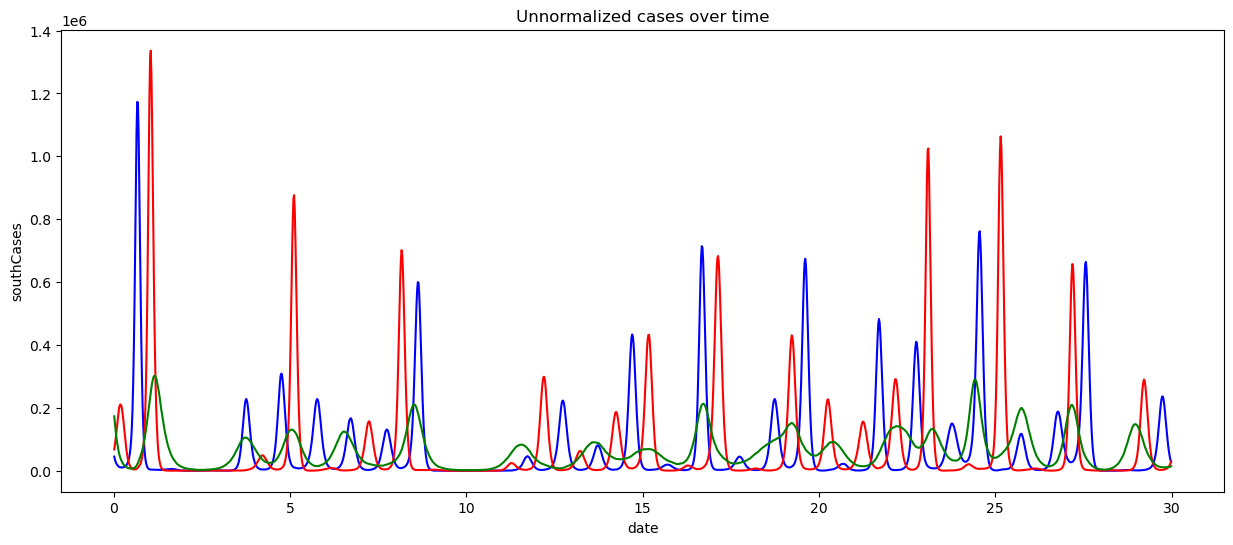

In [63]:
# Plot northcases over time
plt.figure(figsize=(15,6))
sns.lineplot(data=cases_raw, x='date', y='southCases', color='blue')
sns.lineplot(data=cases_raw, x='date', y='northCases', color='red')
sns.lineplot(data=cases_raw, x='date', y='tropicsCases', color='green')
plt.title('Unnormalized cases over time')
plt.show()

In [66]:
cases_df = prep_cases_dataframe(cases_raw)
# For any rows that have the same value for date and country, sum the cases
cases_df = cases_df.groupby(['date', 'country']).sum().reset_index()
cases_df.head(15)

,date,country,cases
0,2020-01-05,north,225
1,2020-01-05,south,149
2,2020-01-05,tropics,576
3,2020-01-11,north,277
4,2020-01-11,south,119
5,2020-01-11,tropics,497
6,2020-01-18,north,333
7,2020-01-18,south,97
8,2020-01-18,tropics,428
9,2020-01-26,north,399


In [67]:
# Write cases to both builds
cases_df.to_csv(f"{ag_data_path}case_counts.tsv", sep='\t', index=False)
cases_df.to_csv(f"{seq_data_path}case_counts.tsv", sep='\t', index=False)